### *Coffee Shop Sales Analysis*
#### *Objective:*
To analyze factors that influence the sales performance in a coffee shop and to understand the underlying trends and patterns for better decision-making

This notebook implements end-to-end Exploratory Data Analysis (EDA) on coffe_shop_sales dataset

#### *The steps are as follows:*
- Data Understanding
- Data Quality
- Data Cleaning and Feature Engineering
- Univariate Analysis
- Bivariate and Multivariate Analysis
- Key Insights and Findings
- Dashboard Creation

In [96]:
# Importing the necessary libraries into the environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [97]:
# Ensuring that all the columns of the coffee_shop_sales dataset are visible
pd.set_option('display.max_column',None)

#### *Data Understanding*

In [98]:
# Loading the coffee_shop_sales dataset into the environment
shop_analysis = pd.read_excel('coffee_shop_sales.xlsx')

In [99]:
# Displaying the first five rows of the shop_analysis dataframe
shop_analysis.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [100]:
# Displaying the number of rows and columns in the shop_analysis dataframe
shop_analysis.shape

(149116, 11)

In [101]:
# Displaying the columns of the shop_analysis dataframe
shop_analysis.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [102]:
# Displaying the datatypes of each columns of the dataframe
shop_analysis.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [103]:
# Displaying a concise summary about the shop_analysis dataframe
shop_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


#### *Insights after Data Understanding*
- There are 1,49,116 rows and 11 columns in the shop_analysis dataframe
- There are 5 categorical, 5 numerical and 1 datetime datatype columns in the shop_analysis dataframe

#### *Data Quality*

In [104]:
# Checking for any null values in the shop_analysis dataframe
shop_analysis.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [105]:
# Checking for duplicated records in the shop_analysis dataframe
shop_analysis.duplicated().sum()

np.int64(0)

In [106]:
# Dividing the columns of the dataframe based on their respective datatype
categorical_cols = shop_analysis.select_dtypes('object').columns
numerical_cols = shop_analysis.select_dtypes(['int','float64']).columns

In [107]:
# Displaying the unique values in each categorical column of the shop_analysis dataframe
for cols in categorical_cols:
    print(f'The unique values in {cols} column: ')
    print(shop_analysis[cols].unique())

The unique values in transaction_time column: 
[datetime.time(7, 6, 11) datetime.time(7, 8, 56) datetime.time(7, 14, 4)
 ... datetime.time(10, 34, 30) datetime.time(12, 3, 24)
 datetime.time(16, 59, 49)]
The unique values in store_location column: 
['Lower Manhattan' "Hell's Kitchen" 'Astoria']
The unique values in product_category column: 
['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']
The unique values in product_type column: 
['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']
The unique values

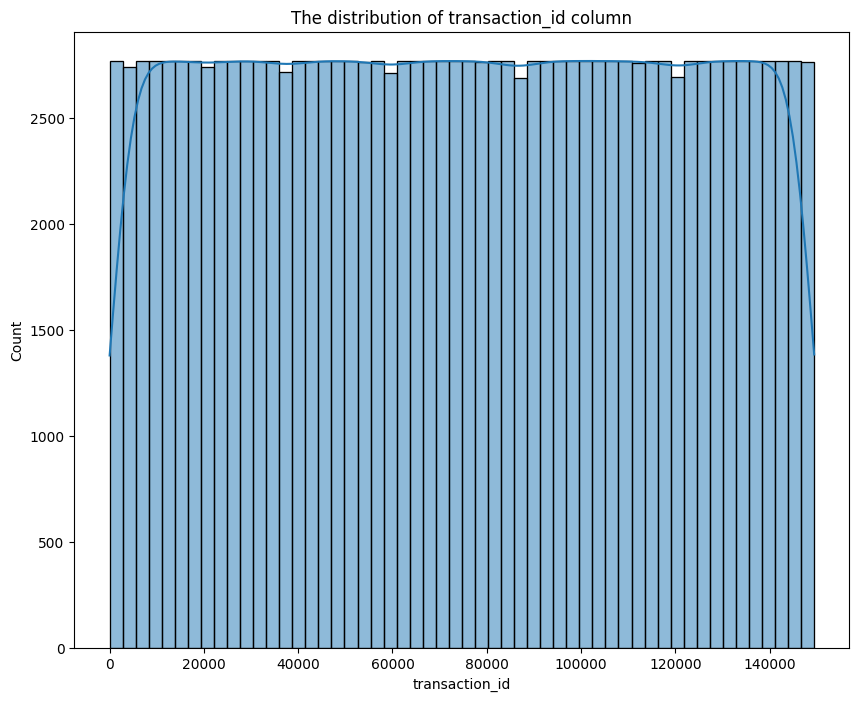

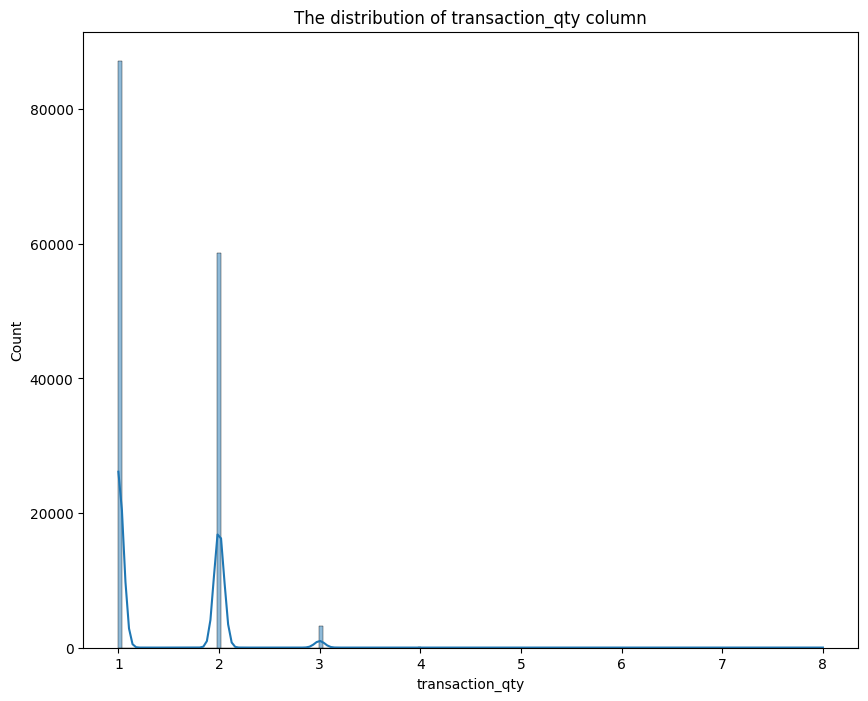

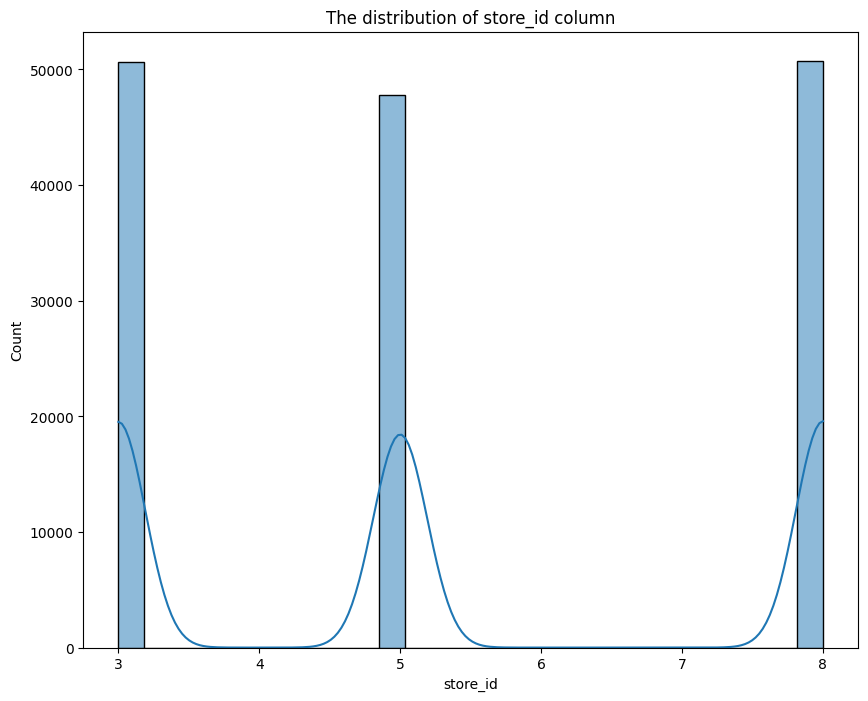

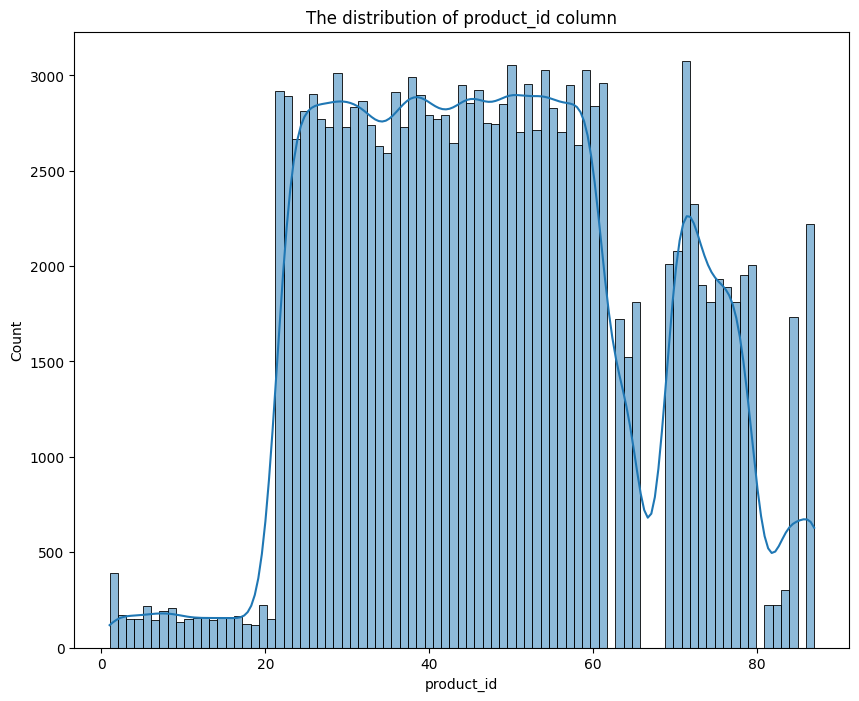

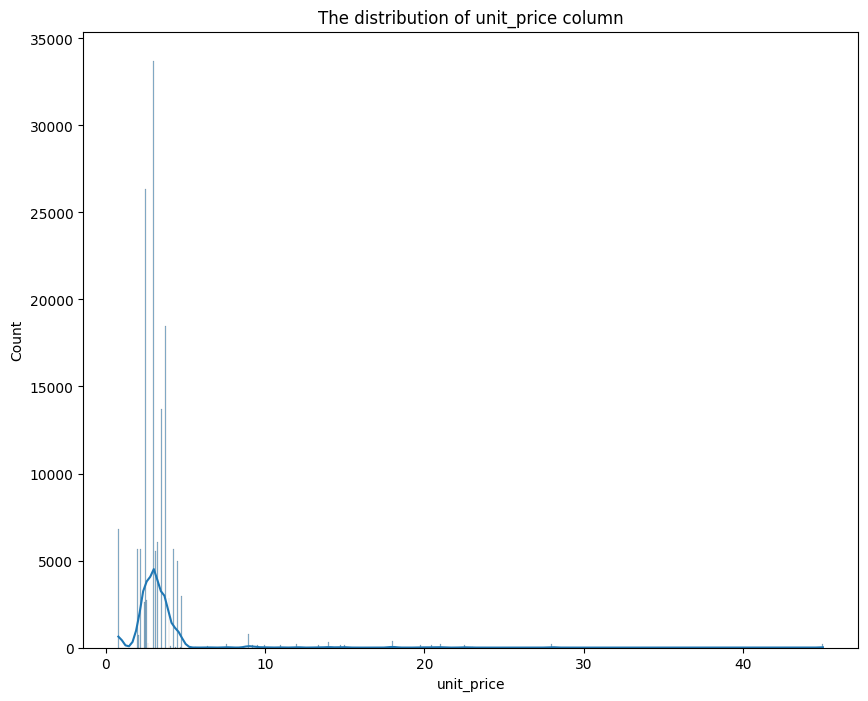

In [108]:
# Displaying the distribution of numerical column of the shop_analysis dataframe
for cols in numerical_cols:
    plt.figure(figsize=(10,8))
    sns.histplot(shop_analysis[cols],kde=True)
    plt.title(f'The distribution of {cols} column')
    plt.show()

#### *Insights after Data Quality*
- There are no missing values in shop_analysis dataframe
- There are no duplicated records in the shop_analysis dataframe
- Most categorical columns of the dataframe are ubiform and do not require any form of standardizations
- New columns can be engineered from categorical columns of the dataframe
- Most numerical columns of the dataframe are of good quality and distributed with no visible outliers or impossible values so far
- The datatype of store_id need to changed from numerical to categorical as it peaks at 3 different points
- The datatype of product_id is not to be treated as continuous but as a category
- The columns transaction_qty and unit_price are right skewed, indicating that most customers prefer the cheaper variety of coffee and other products

#### *Data Cleaning*

In [109]:
# Changing the datatype of store_id column from numerical to categorical datatype
shop_analysis['store_id'] = shop_analysis['store_id'].astype('object')

# Changing the datatype of product_id column from numerical to category datatype
shop_analysis['product_id'] = shop_analysis['product_id'].astype('category')

# Changing the datatype of transaction time from object to datetime datatype
shop_analysis['transaction_time'] = pd.to_datetime(shop_analysis['transaction_time'].astype('str'))

C:\Users\ICG312\AppData\Local\Temp\ipykernel_20192\413023353.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shop_analysis['transaction_time'] = pd.to_datetime(shop_analysis['transaction_time'].astype('str'))


In [110]:
# Checking if the datatypes of the columns were changed
shop_analysis.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time    datetime64[ns]
transaction_qty              int64
store_id                    object
store_location              object
product_id                category
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

The distribution of missing values in shop_analysis dataframe:

               index    0
0     transaction_id  0.0
1   transaction_date  0.0
2   transaction_time  0.0
3    transaction_qty  0.0
4           store_id  0.0
5     store_location  0.0
6         product_id  0.0
7         unit_price  0.0
8   product_category  0.0
9       product_type  0.0
10    product_detail  0.0


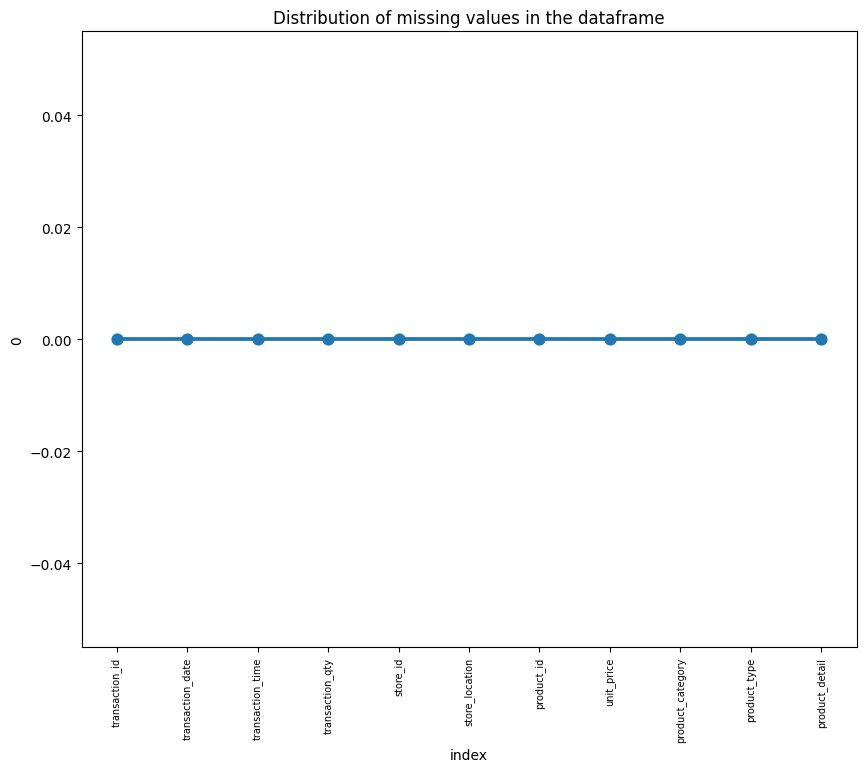

In [111]:
# Displaying the distribution of missing values in across the shop_analysis dataframe
missing = (shop_analysis.isnull().sum()*100/shop_analysis.shape[0]).reset_index()
print('The distribution of missing values in shop_analysis dataframe:\n')
print(missing)

# Visualizing the distribution of missing values across the dataframe
plt.figure(figsize=(10,8))
sns.pointplot(data=missing, x='index',y=0)
plt.xticks(rotation=90, fontsize=7)
plt.title('Distribution of missing values in the dataframe')
plt.show()

In [112]:
# Creating a new column 'size' from product_detail column by extracting the sizes of the drinks
shop_analysis['size'] = shop_analysis['product_detail'].str.extract(r'\b(Sm|Rg|Lg)\b')

# Displaying if the 'size' column has been created in the shop_analysis dataframe
shop_analysis[['product_detail','size']].sample(5)

,product_detail,size
112018,Columbian Medium Roast Lg,Lg
132002,Brazilian Rg,Rg
69957,Jumbo Savory Scone,NaN
146259,Lemon Grass Rg,Rg
94802,Chocolate Chip Biscotti,NaN


In [113]:
# Standardizing the 'size' column of the shop_analysis dataframe
shop_analysis['size'] = shop_analysis['size'].replace({
    'Rg': 'regular',
    'Lg': 'large',
    'Sm': 'small'
})

# Replacing the 'NaN' values in the shop_analysis dataframe by replacing with 'standard'
shop_analysis['size'] = shop_analysis['size'].fillna('standard')

# Displaying the unique values in 'size' column of the shop_analysis dataframe
shop_analysis['size'].unique()

array(['regular', 'large', 'small', 'standard'], dtype=object)

In [114]:
# Creating a separate column 'product_name' by extracting the name from the product_detail column of the dataframe
shop_analysis['product_name'] = shop_analysis['product_detail'].str.replace(r'\s(Sm|Rg|Lg)$','',regex=True)

In [115]:
# Extracting year, month and day from the transaction_date column of the shop_analysis dataframe
shop_analysis['transaction_year'] = shop_analysis['transaction_date'].dt.year
shop_analysis['transaction_month'] = shop_analysis['transaction_date'].dt.month_name()
shop_analysis['transaction_day'] = shop_analysis['transaction_date'].dt.day_name()

# Extracting the hours from the transaction_time column of the shop_analysis dataframe
shop_analysis['hour'] = shop_analysis['transaction_time'].dt.hour

In [116]:
# Creating bins using the hour column of the shop_analysis dataframe
shop_analysis['time_of_day'] = pd.cut(shop_analysis['hour'],
                bins =[0,12,17,21,24], labels =['morning','afternoon','evening','night'],
                right=False)

# Displaying the 'time_of_day' column of the shop_analysis dataframe
shop_analysis[['hour','time_of_day']].sample(5)

,hour,time_of_day
3985,9,morning
30691,18,evening
3508,10,morning
67772,8,morning
22741,11,morning


In [117]:
# Creating a new column total_amount by multiplying traansaction_qty and unit_price
shop_analysis['total_amount'] = (shop_analysis['transaction_qty'] * shop_analysis['unit_price'])

In [118]:
shop_analysis.sample(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,size,product_name,transaction_year,transaction_month,transaction_day,hour,time_of_day,total_amount
46069,46176,2023-03-18,2026-03-04 17:09:21,1,3,Astoria,6,21.00,Coffee beans,Gourmet Beans,Ethiopia,standard,Ethiopia,2023,March,Saturday,17,evening,21.00
134758,135095,2023-06-18,2026-03-04 14:15:17,1,3,Astoria,56,2.55,Tea,Brewed Chai tea,Spicy Eye Opener Chai Rg,regular,Spicy Eye Opener Chai,2023,June,Sunday,14,afternoon,2.55
10462,10492,2023-01-19,2026-03-04 09:14:54,1,8,Hell's Kitchen,87,2.10,Coffee,Barista Espresso,Ouro Brasileiro shot,standard,Ouro Brasileiro shot,2023,January,Thursday,9,morning,2.10
70036,70206,2023-04-18,2026-03-04 16:32:52,1,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm,small,Columbian Medium Roast,2023,April,Tuesday,16,afternoon,2.00
27830,27887,2023-02-19,2026-03-04 07:46:17,2,8,Hell's Kitchen,25,2.20,Coffee,Organic brewed coffee,Brazilian Sm,small,Brazilian,2023,February,Sunday,7,morning,4.40
57329,57440,2023-04-03,2026-03-04 19:35:54,1,8,Hell's Kitchen,61,4.75,Drinking Chocolate,Hot chocolate,Sustainably Grown Organic Lg,large,Sustainably Grown Organic,2023,April,Monday,19,evening,4.75
90375,90629,2023-05-10,2026-03-04 10:28:49,1,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg,regular,Dark chocolate,2023,May,Wednesday,10,morning,3.50
66764,66934,2023-04-15,2026-03-04 08:07:40,2,8,Hell's Kitchen,38,3.75,Coffee,Barista Espresso,Latte,standard,Latte,2023,April,Saturday,8,morning,7.50
118688,118950,2023-06-05,2026-03-04 12:19:01,1,3,Astoria,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,large,Spicy Eye Opener Chai,2023,June,Monday,12,afternoon,3.10
57240,57351,2023-04-03,2026-03-04 18:14:19,2,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,large,Peppermint,2023,April,Monday,18,evening,6.00


In [119]:
# Dropping the unecessary columns of the shop_analysis dataframe
shop_analysis = shop_analysis.drop(columns=['transaction_date','transaction_time','product_detail'])

In [120]:
# Rearranging the columns of the shop_analysis dataframe
shop_analysis = shop_analysis[[
    'transaction_id', 'transaction_year','transaction_month','transaction_day','hour',
    'time_of_day','store_id', 'store_location','product_id', 'product_category',
    'product_type',	'size',	'product_name','unit_price','transaction_qty', 'total_amount'
]]

In [121]:
# Displaying the 10 samples from the shop_analysis dataframe
shop_analysis.sample(10)

,transaction_id,transaction_year,transaction_month,transaction_day,hour,time_of_day,store_id,store_location,product_id,product_category,product_type,size,product_name,unit_price,transaction_qty,total_amount
15117,15147,2023,January,Friday,10,morning,5,Lower Manhattan,59,Drinking Chocolate,Hot chocolate,large,Dark chocolate,4.50,1,4.50
85241,85415,2023,May,Friday,17,evening,8,Hell's Kitchen,46,Tea,Brewed Green tea,regular,Serenity Green Tea,2.50,1,2.50
89861,90115,2023,May,Wednesday,7,morning,5,Lower Manhattan,38,Coffee,Barista Espresso,standard,Latte,3.75,2,7.50
89971,90225,2023,May,Wednesday,7,morning,3,Astoria,43,Tea,Brewed herbal tea,large,Lemon Grass,3.00,2,6.00
20293,20323,2023,February,Monday,12,afternoon,3,Astoria,44,Tea,Brewed herbal tea,regular,Peppermint,2.50,2,5.00
41278,41385,2023,March,Sunday,8,morning,5,Lower Manhattan,30,Coffee,Gourmet brewed coffee,large,Columbian Medium Roast,3.00,2,6.00
78953,79123,2023,April,Saturday,10,morning,8,Hell's Kitchen,69,Bakery,Biscotti,standard,Hazelnut Biscotti,3.25,1,3.25
7800,7830,2023,January,Saturday,19,evening,8,Hell's Kitchen,44,Tea,Brewed herbal tea,regular,Peppermint,2.50,1,2.50
39370,39477,2023,March,Thursday,10,morning,5,Lower Manhattan,77,Bakery,Scone,standard,Oatmeal Scone,3.00,1,3.00
45117,45224,2023,March,Friday,10,morning,5,Lower Manhattan,51,Tea,Brewed Black tea,large,Earl Grey,3.00,2,6.00


In [122]:
# Displaying the number of rows and columns in the new shop_analysis dataframe
shop_analysis.shape

(149116, 16)

#### *Insights after Data Cleaning and Feature Engineering*
- Converting the store_id to object datatype, product_id to category datatype and the transaction_time to datetime datatype
- There are no missing and duplicated records in the dataframe that needed to be handled
- A new column size was created by extracting the sizes from the product_detail column of the shop_analysis dataframe and products without sizes were replaced by NaN
- The size column was standardized to maintain uniformity and the NaN values were replaced by standard
- A new column named product_name was created ny extracting the product names from the product_detail column of the shop_analysis dataframe
- The year, month and day of the week were extracted from transaction_date column whereas the hours were extracted from transaction_time column of the shop_analysis dataframe
- A new column time_of_day was created using hour column to indicated the when the purchase was done (morning, afternoon, evening or night)
- The column total_amount was created by multiply transaction_qty and unit_price, indicating the purchase conducted by a single customer
- The columns transaction_date, transaction_time and product_details were dropped as they provide no analytical value
- The new shop_analysis dataframe has 1,49,116 records and 16 columns, the increase in columns is due to the new columns that were engineered

In [123]:
# Dividing the columns of the dataframe based on datatype of their respective columns
category_cols = shop_analysis.select_dtypes('object').columns
numeric_cols = shop_analysis.select_dtypes(['int','float64']).columns

#### *Univariate Analysis*

In [124]:
# Performing a datatype validation on the columns of the shop_analysis
shop_analysis.dtypes

transaction_id          int64
transaction_year        int32
transaction_month      object
transaction_day        object
hour                    int32
time_of_day          category
store_id               object
store_location         object
product_id           category
product_category       object
product_type           object
size                   object
product_name           object
unit_price            float64
transaction_qty         int64
total_amount          float64
dtype: object

In [125]:
# Displaying the statistical summary of the shop_analysis dataframe
shop_analysis.describe(include='all')

,transaction_id,transaction_year,transaction_month,transaction_day,hour,time_of_day,store_id,store_location,product_id,product_category,product_type,size,product_name,unit_price,transaction_qty,total_amount
count,149116.000000,149116.0,149116,149116,149116.000000,149116,149116.0,149116,149116.0,149116,149116,149116,149116,149116.000000,149116.000000,149116.000000
unique,NaN,NaN,6,7,NaN,3,3.0,3,80.0,9,29,4,45,NaN,NaN,NaN
top,NaN,NaN,June,Friday,NaN,morning,8.0,Hell's Kitchen,71.0,Coffee,Brewed Chai tea,regular,Our Old Time Diner Blend,NaN,NaN,NaN
freq,NaN,NaN,35352,21701,NaN,81751,50735.0,50735,3076.0,58416,17183,45789,8660,NaN,NaN,NaN
mean,74737.371872,2023.0,NaN,NaN,11.735790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.382219,1.438276,4.686367
std,43153.600016,0.0,NaN,NaN,3.764662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.658723,0.542509,4.227099
min,1.000000,2023.0,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.800000,1.000000,0.800000
25%,37335.750000,2023.0,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,1.000000,3.000000
50%,74727.500000,2023.0,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,3.750000
75%,112094.250000,2023.0,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.750000,2.000000,6.000000


In [126]:
# Displaying the limits of the numerical columns of the shop_analysis dataframe
for cols in numeric_cols:
    print(f'The maximum value in {cols} column is: ',shop_analysis[cols].max())
    print(f'The minimum value in {cols} column is: ',shop_analysis[cols].min())
    print(f'The range of the {cols} column is: ',shop_analysis[cols].max() - shop_analysis[cols].min())
    print(f'The mean of the {cols} column is: ',shop_analysis[cols].mean())
    print(f'The standard deviation of the {cols} column is: ',shop_analysis[cols].std())

The maximum value in transaction_id column is:  149456
The minimum value in transaction_id column is:  1
The range of the transaction_id column is:  149455
The mean of the transaction_id column is:  74737.37187156308
The standard deviation of the transaction_id column is:  43153.6000159179
The maximum value in transaction_year column is:  2023
The minimum value in transaction_year column is:  2023
The range of the transaction_year column is:  0
The mean of the transaction_year column is:  2023.0
The standard deviation of the transaction_year column is:  0.0
The maximum value in hour column is:  20
The minimum value in hour column is:  6
The range of the hour column is:  14
The mean of the hour column is:  11.735789586630542
The standard deviation of the hour column is:  3.7646615223937197
The maximum value in unit_price column is:  45.0
The minimum value in unit_price column is:  0.8
The range of the unit_price column is:  44.2
The mean of the unit_price column is:  3.3822194130743855


In [127]:
# Displaying the skewness and the kurtosis value of the numeric columns of the dataframe
for cols in numeric_cols:
    print(f'The skewness of the {cols} column is: ',shop_analysis[cols].skew())
    print(f'The kurtosis of the {cols} column is: ',shop_analysis[cols].kurtosis())

The skewness of the transaction_id column is:  6.194436090069795e-05
The kurtosis of the transaction_id column is:  -1.200450541240584
The skewness of the transaction_year column is:  0.0
The kurtosis of the transaction_year column is:  0.0
The skewness of the hour column is:  0.4091263560778122
The kurtosis of the hour column is:  -1.041784856537548
The skewness of the unit_price column is:  8.455087629230462
The kurtosis of the unit_price column is:  98.91941109848163
The skewness of the transaction_qty column is:  0.7998191159712718
The kurtosis of the transaction_qty column is:  0.8236924055807595
The skewness of the total_amount column is:  41.74589939197431
The kurtosis of the total_amount column is:  3359.754588548663


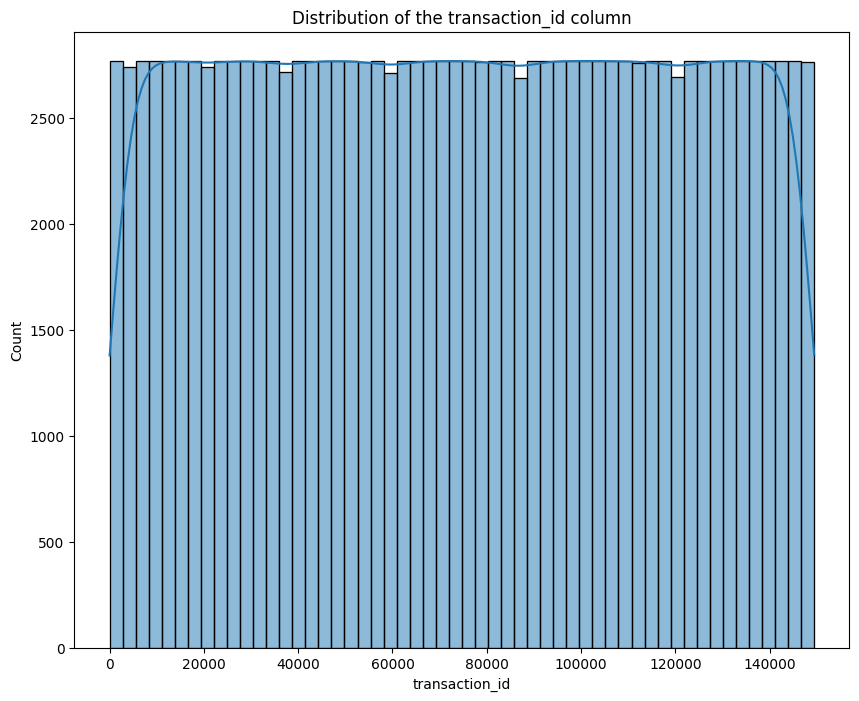

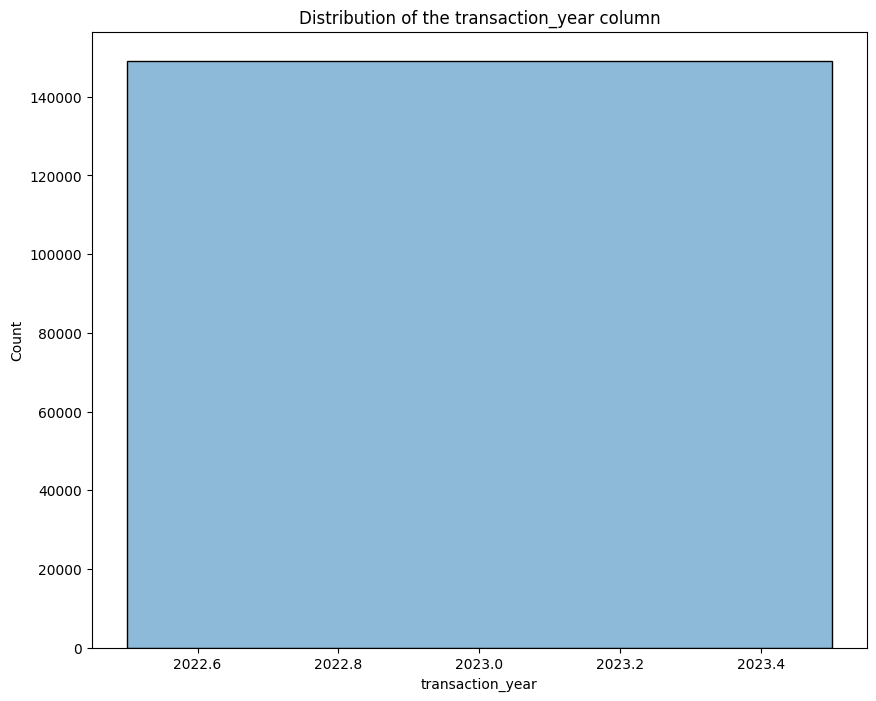

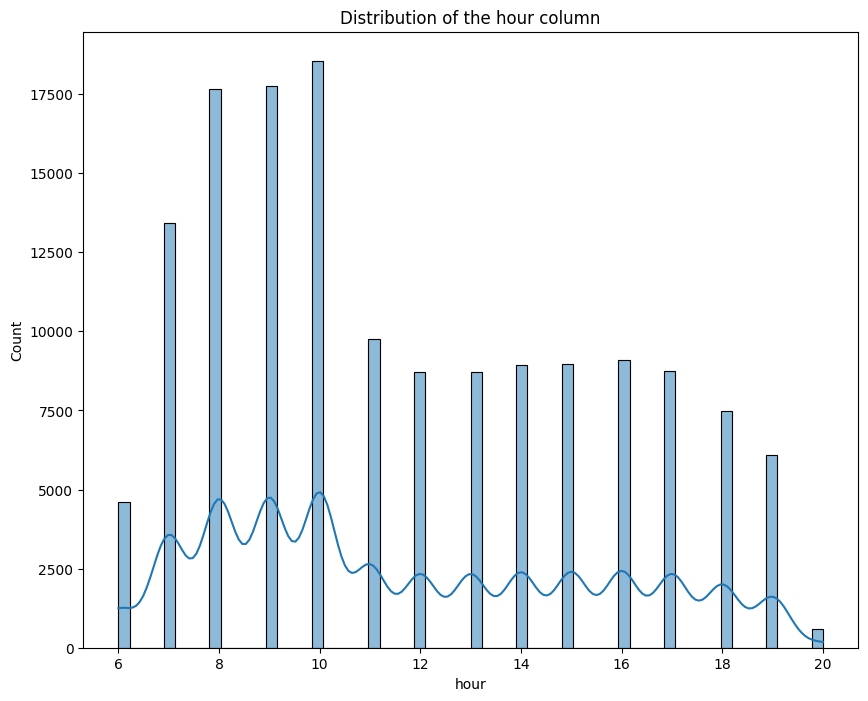

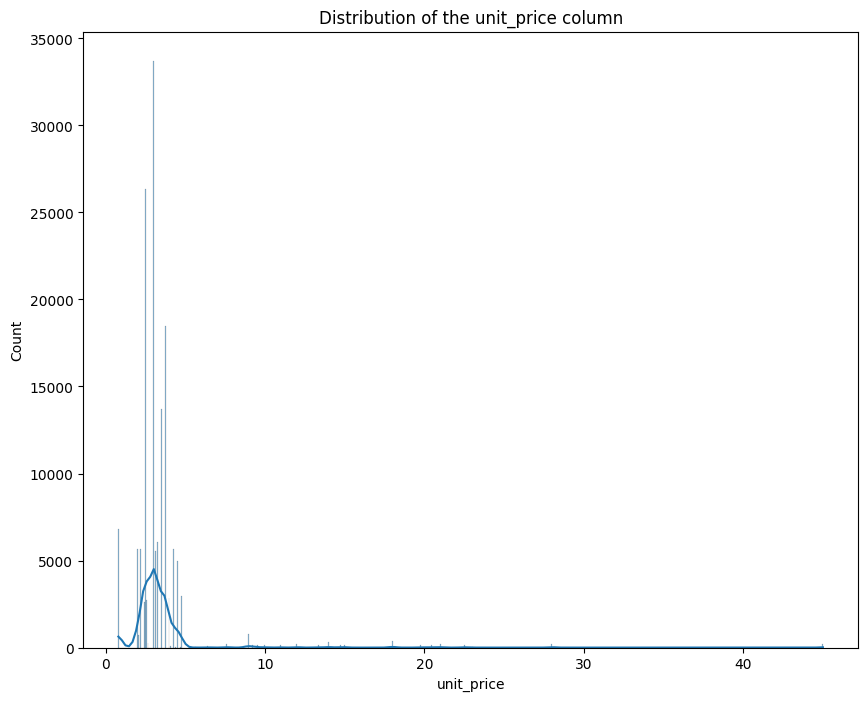

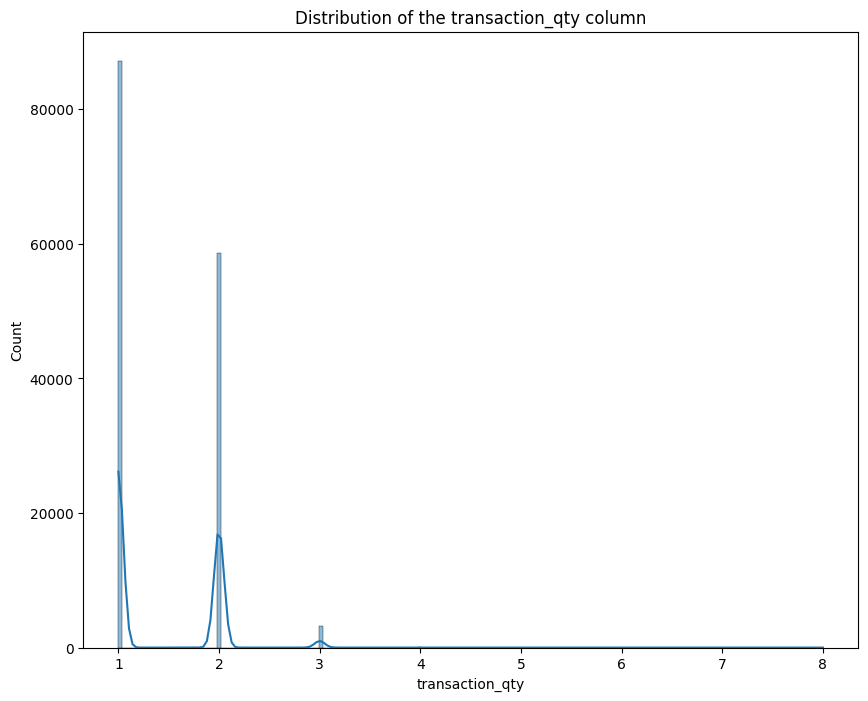

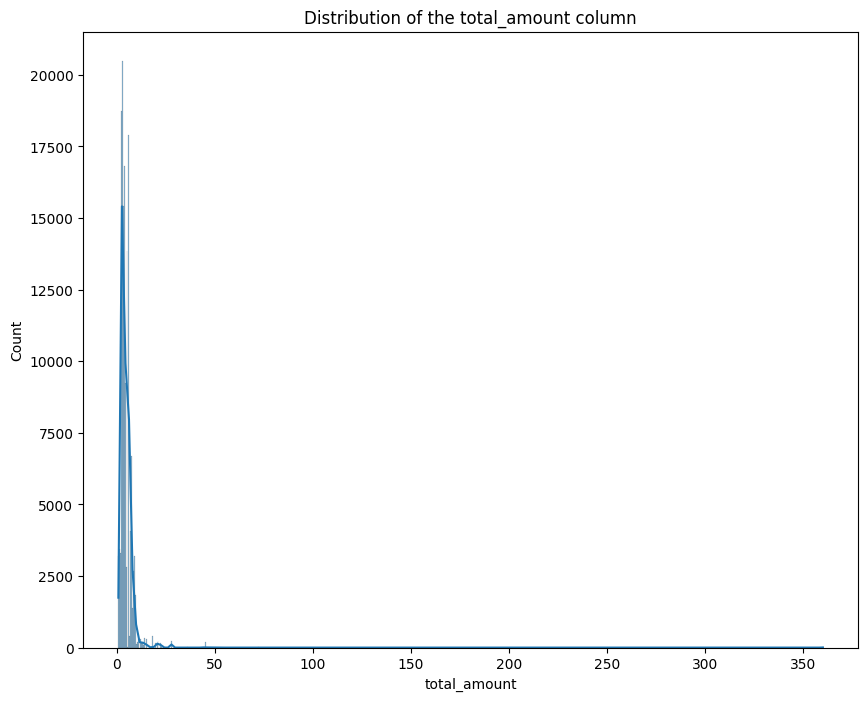

In [128]:
# Visualizing the distribution of the numerical columns across the shop_analysis dataframe
for cols in numeric_cols:
    plt.figure(figsize=(10,8))
    sns.histplot(shop_analysis[cols],kde=True)
    plt.title(f'Distribution of the {cols} column')
    plt.show()

The distibution of transaction_month column:

transaction_month
June        23.707717
May         22.483838
April       16.990128
March       14.236568
January     11.611095
February    10.970654
Name: count, dtype: float64


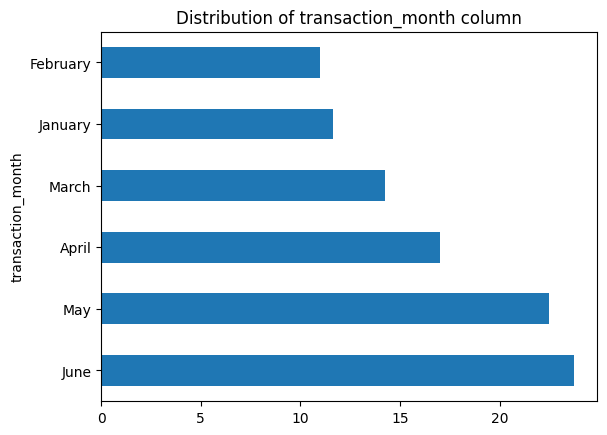

The distibution of transaction_day column:

transaction_day
Friday       14.553100
Thursday     14.521581
Monday       14.514204
Wednesday    14.290888
Tuesday      14.218461
Sunday       14.147375
Saturday     13.754393
Name: count, dtype: float64


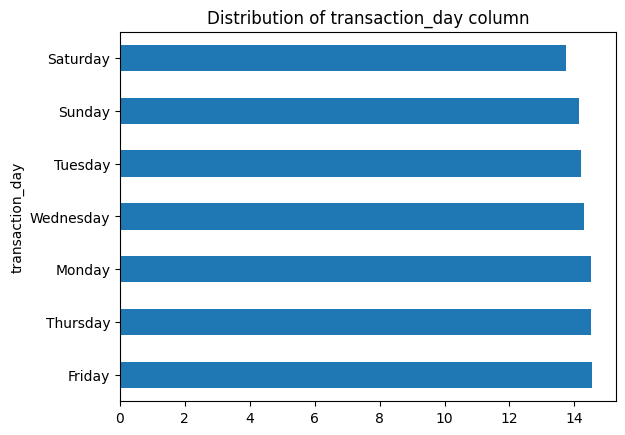

The distibution of store_id column:

store_id
8    34.023847
3    33.932643
5    32.043510
Name: count, dtype: float64


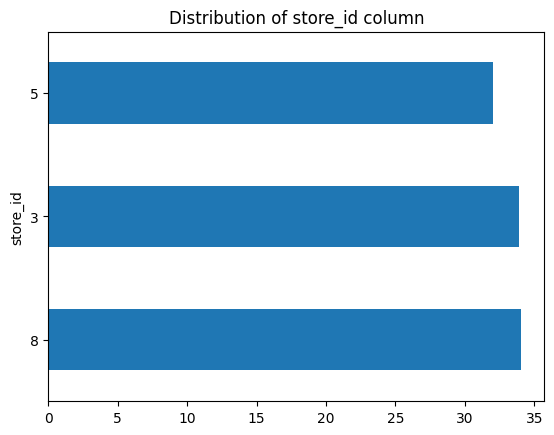

The distibution of store_location column:

store_location
Hell's Kitchen     34.023847
Astoria            33.932643
Lower Manhattan    32.043510
Name: count, dtype: float64


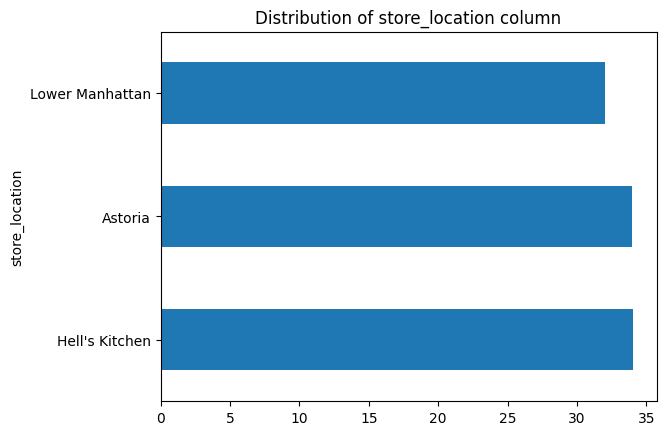

The distibution of product_category column:

product_category
Coffee                39.174871
Tea                   30.478956
Bakery                15.287427
Drinking Chocolate     7.690657
Flavours               4.553502
Coffee beans           1.175595
Loose Tea              0.811449
Branded                0.500952
Packaged Chocolate     0.326591
Name: count, dtype: float64


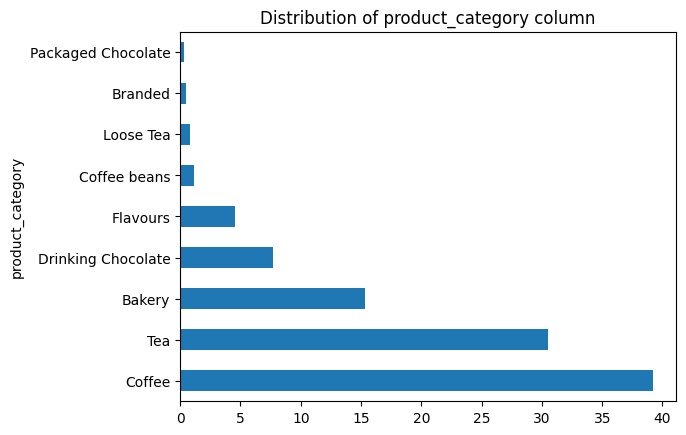

The distibution of product_type column:

product_type
Brewed Chai tea          11.523244
Gourmet brewed coffee    11.341506
Barista Espresso         11.000161
Hot chocolate             7.690657
Brewed Black tea          7.611524
Brewed herbal tea         7.541109
Scone                     6.822206
Organic brewed coffee     5.692883
Drip coffee               5.684836
Premium brewed coffee     5.455484
Pastry                    4.635317
Biscotti                  3.829904
Brewed Green tea          3.803079
Regular syrup             3.339011
Sugar free syrup          1.214491
Housewares                0.352746
Chai tea                  0.297084
Organic Beans             0.278307
Gourmet Beans             0.245446
Premium Beans             0.225328
Espresso Beans            0.213927
Herbal tea                0.204539
Black tea                 0.203198
Drinking Chocolate        0.178385
Organic Chocolate         0.148207
Clothing                  0.148207
House blend Beans         0.122723
G

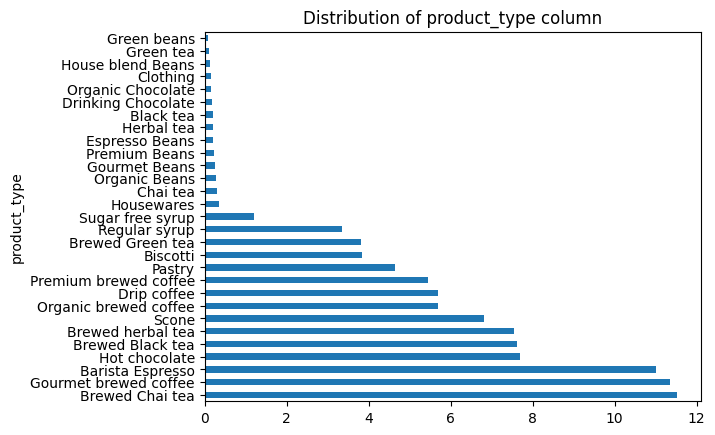

The distibution of size column:

size
regular     30.706966
large       30.100727
standard    29.854610
small        9.337697
Name: count, dtype: float64


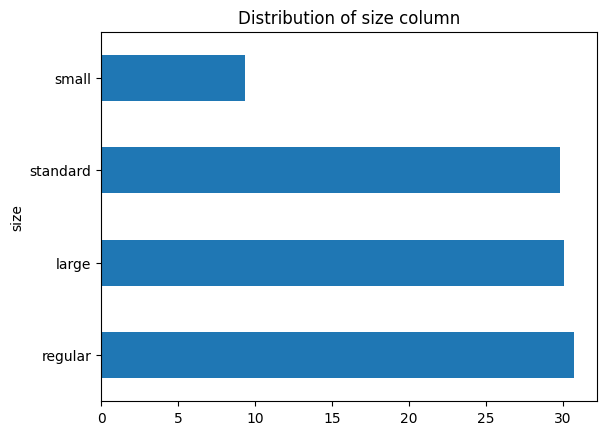

The distibution of product_name column:

product_name
Our Old Time Diner Blend        5.807559
Ethiopia                        5.806218
Columbian Medium Roast          5.780734
Brazilian                       5.692883
Jamaican Coffee River           5.455484
Sustainably Grown Organic       4.039808
Morning Sunrise Chai            4.039808
Peppermint                      3.996218
Earl Grey                       3.954639
Latte                           3.947263
Serenity Green Tea              3.909708
Traditional Blend Chai          3.905684
Dark chocolate                  3.878189
Spicy Eye Opener Chai           3.874836
English Breakfast               3.860082
Lemon Grass                     3.749430
Cappuccino                      3.731994
Chocolate Croissant             2.062824
Espresso shot                   1.830789
Ginger Scone                    1.558518
Ouro Brasileiro shot            1.490115
Cranberry Scone                 1.392875
Hazelnut Biscotti               1.347273
Jum

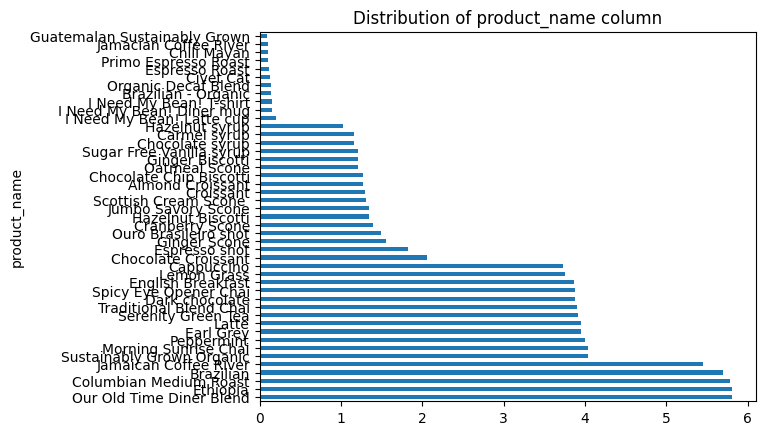

In [129]:
# Displaying the ditribution of values in the categorical columns of the shop_analysis dataframe
for cols in category_cols:
    distribution = (shop_analysis[cols].value_counts() * 100/shop_analysis.shape[0])
    print(f'The distibution of {cols} column:\n')
    print(distribution)
    # Visualizing the distribution of categorical columns of the dataframe
    distribution.plot(kind='barh')
    plt.title(f'Distribution of {cols} column')
    plt.show()

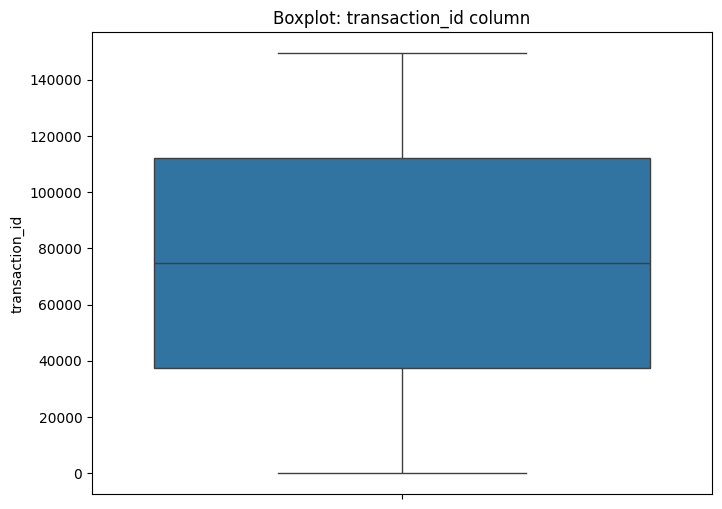

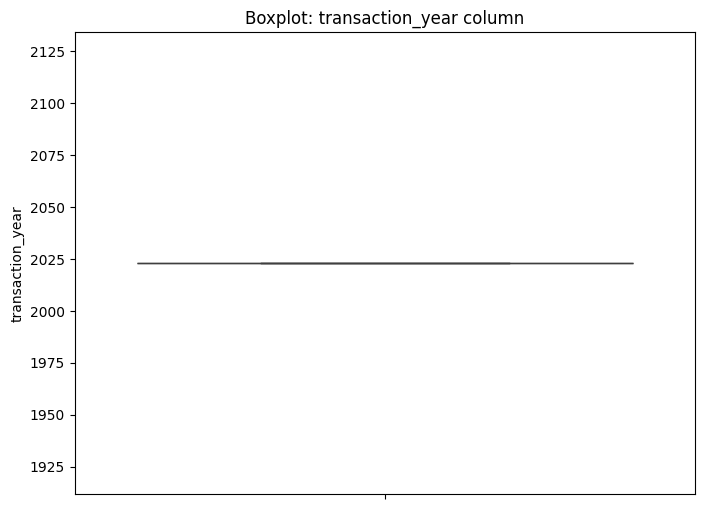

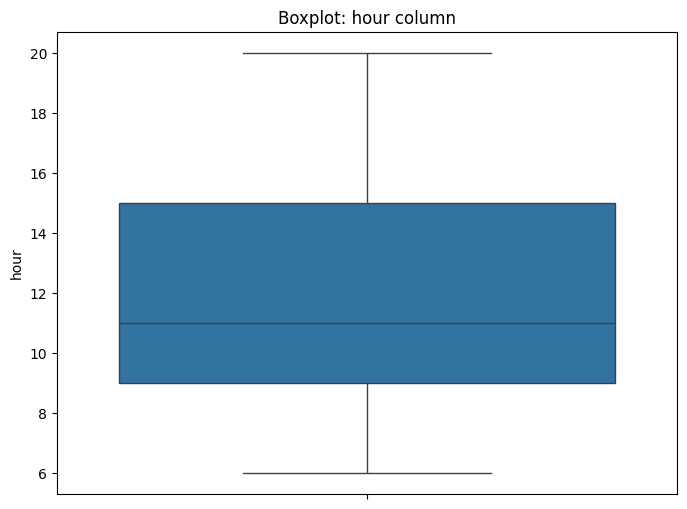

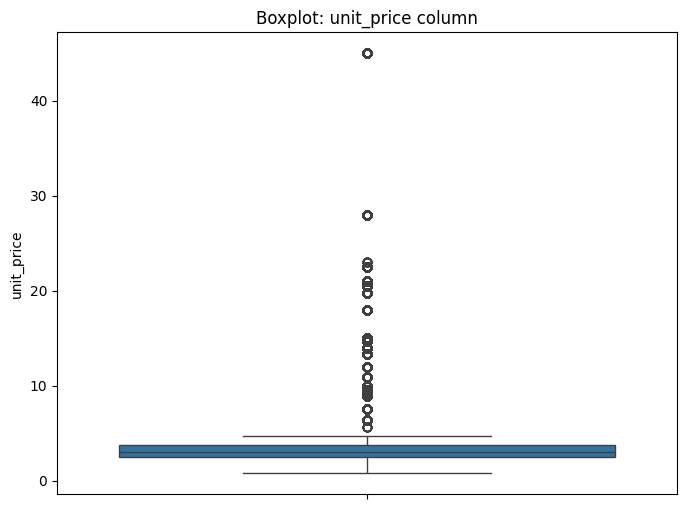

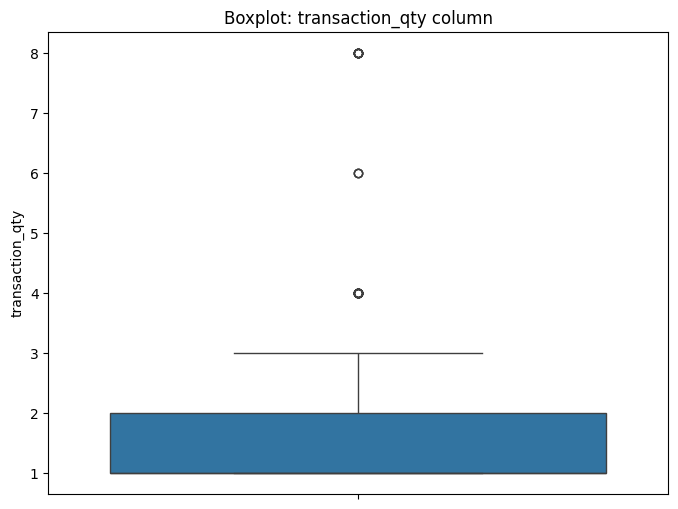

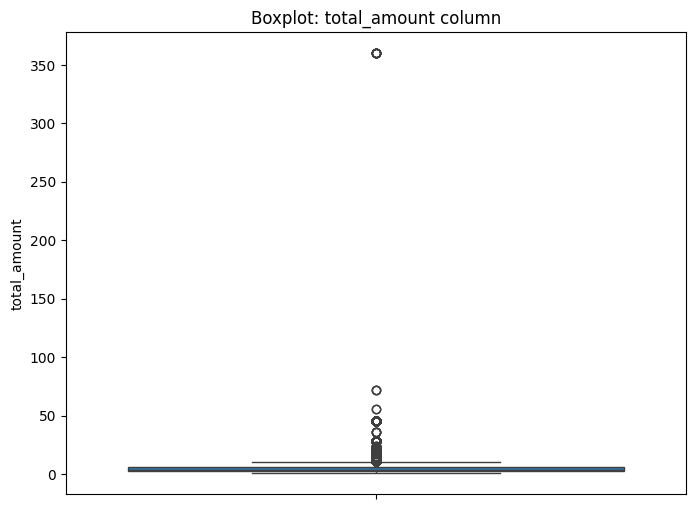

In [130]:
# Checking for any outliers in the shop_analysis dataframe
for cols in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(shop_analysis[cols])
    plt.title(f'Boxplot: {cols} column')

#### *Insights after Univariate Analysis*
- There are 10 categorical and 6 numerical columns in the shop_analysis dataframe
- All the transactions in the dataframe happen in the year 2023 and the column has symmetrical skewness and a normal distribution
- The transaction occur between 6 am - 8 pm with most occuring between 8 am and 2 pm. The most frequent transactions happen at 10 am. The column is almost symmetrical and might contain a few outliers
- The most expensive product in the store cost $45 with most customers buying with the range of $1 and $5. The column has a positive skew and contains extreme values
- The most quantity bought by a customer is 7 but most customers only buy 1 product. The column has a symmetrical skewness and a normal distribution
- The highest total amount ever spent at a store was $360, with most total amount being around the ranges $0.46 and $9. The column shows positive skewness with presence of extreme values
- The best sales happens in month of June (23%) followed by May (22%)
- Most of the footfall in the shop happens either on a Friday or a Thursday (14%)
- The store with most footfall seems to be Hell's Kitchen (store_id-8) with 34% of the total footfall
- The most sold product category is Coffee is 38 %, followed by Tea at 30%, the most popular product types are Brewed Chai Tea & Gourmet Brewed Coffee both at 11% and the best selling products are Our Old Time Diner Blend and Ethiopia; both accounting for 5 % of the total sales
- The best selling size is regular, ehich account for 30% of the sales
- There seems to be presence of outliers in the unit_price, transaction_qty and total_amount but they seem realistic as shops do offer premium variety that cost more and sometimes customers make bulk purchases. Hence, these columns do not require any additional processing or handling

#### *Bivariate and Multivariate Analysis*

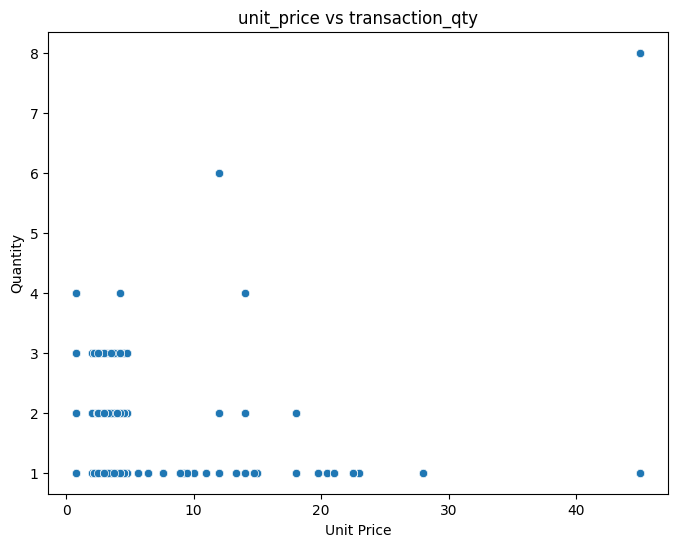

In [131]:
# Visualizing the relationship between price and quantity
plt.figure(figsize=(8,6))
sns.scatterplot(data = shop_analysis, x='unit_price',y='transaction_qty')
plt.title(f'unit_price vs transaction_qty')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.show()

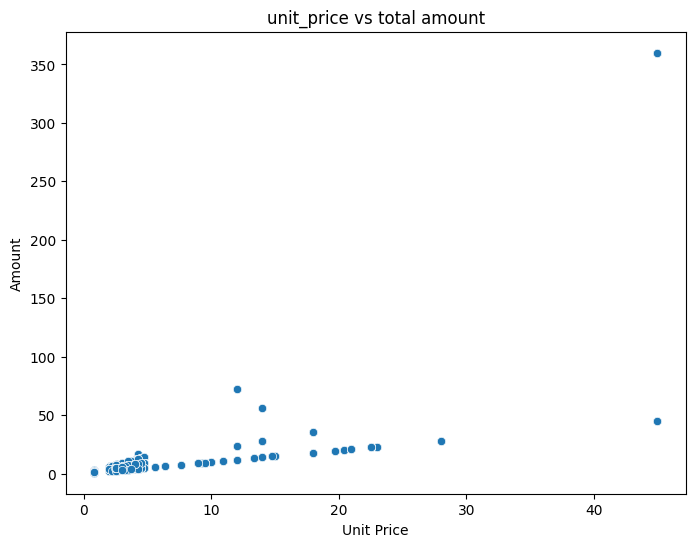

In [132]:
# Visualizing the relationship between price and total amount
plt.figure(figsize=(8,6))
sns.scatterplot(data = shop_analysis, x='unit_price',y='total_amount')
plt.title(f'unit_price vs total amount')
plt.xlabel('Unit Price')
plt.ylabel('Amount')
plt.show()

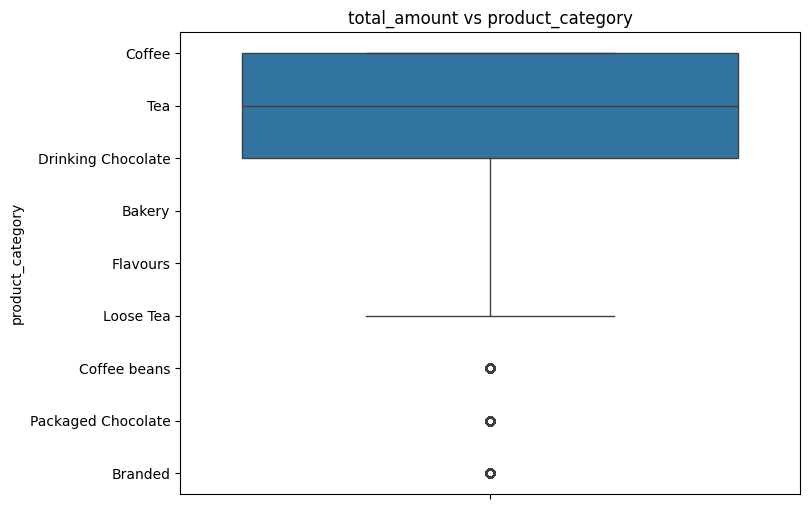

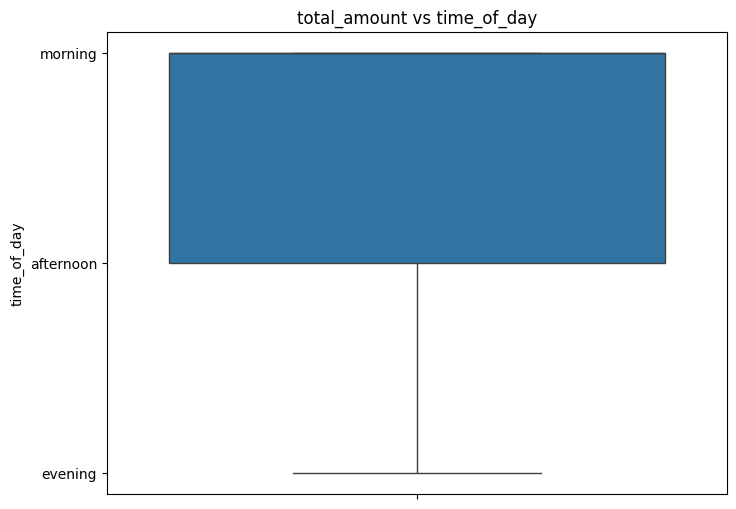

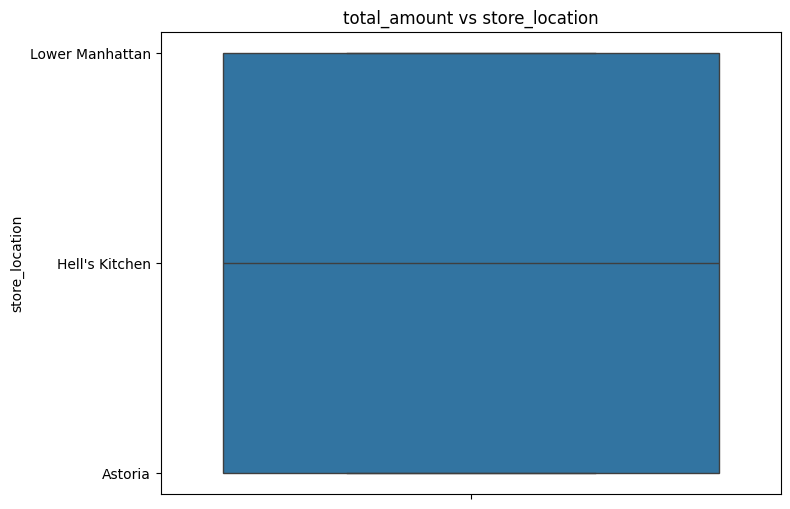

In [133]:
# Visualizing the relationship between total amount vs category, day and store_location
relation = ['product_category','time_of_day','store_location']
for cols in relation:
    plt.figure(figsize=(8,6))
    sns.boxplot(shop_analysis[cols])
    plt.title(f'total_amount vs {cols}')
    plt.show()

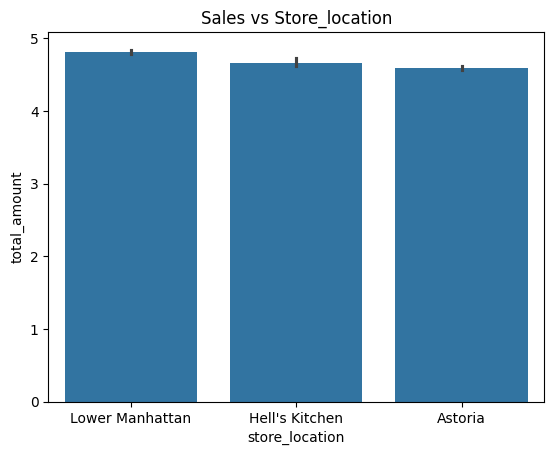

In [134]:
# Visualizing sale per store_location
sns.barplot(data=shop_analysis, x='store_location',y='total_amount')
plt.title('Sales vs Store_location')
plt.show()

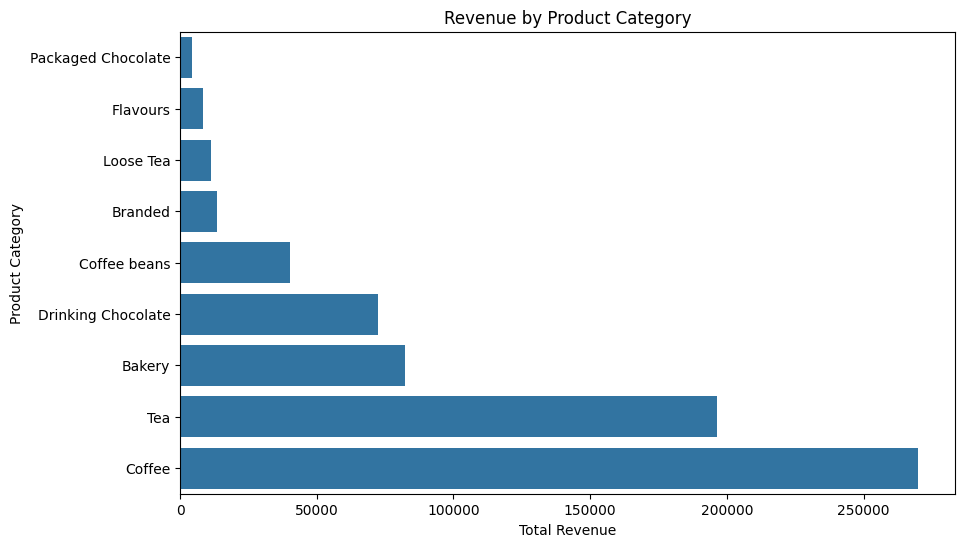

In [135]:
# Revenue by product_category
sales_by_category = shop_analysis.groupby('product_category')['total_amount'].sum().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_category.values, y=sales_by_category.index)
plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()

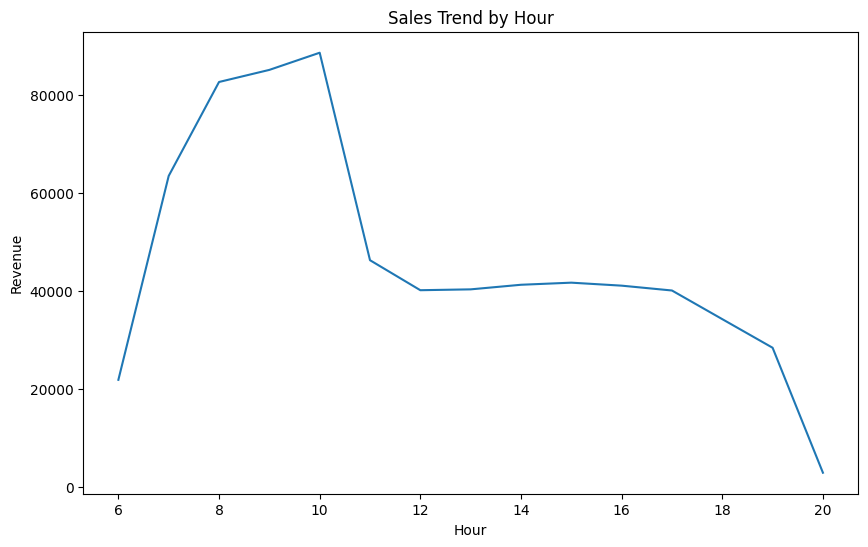

In [136]:
# Sales vs time (hour)
sales_by_hour = shop_analysis.groupby('hour')['total_amount'].sum()
plt.figure(figsize=(10,6))
sns.lineplot(x=sales_by_hour.index, y=sales_by_hour.values)
plt.title("Sales Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

In [143]:
# Top Revenue Products
top_products = shop_analysis.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(10)
top_products

product_name
Ethiopia                     42304.10
Sustainably Grown Organic    39065.10
Jamaican Coffee River        38781.15
Brazilian                    37746.50
Latte                        36369.75
Dark chocolate               35785.70
Our Old Time Diner Blend     35278.00
Columbian Medium Roast       34528.50
Cappuccino                   33639.25
Morning Sunrise Chai         30587.50
Name: total_amount, dtype: float64

In [144]:
# Sales by Month
shop_analysis.groupby('transaction_month')['total_amount'].sum()

transaction_month
April       118941.08
February     76145.19
January      81677.74
June        166485.88
March        98834.68
May         156727.76
Name: total_amount, dtype: float64

store_location      Astoria  Hell's Kitchen  Lower Manhattan
product_category                                            
Bakery                 7289            7617             7890
Branded                 279             119              349
Coffee                20025           20187            18204
Coffee beans            502             720              531
Drinking Chocolate     4300            3763             3405
Flavours               1490            2370             2930
Loose Tea               344             485              381
Packaged Chocolate      110             197              180
Tea                   16260           15277            13912


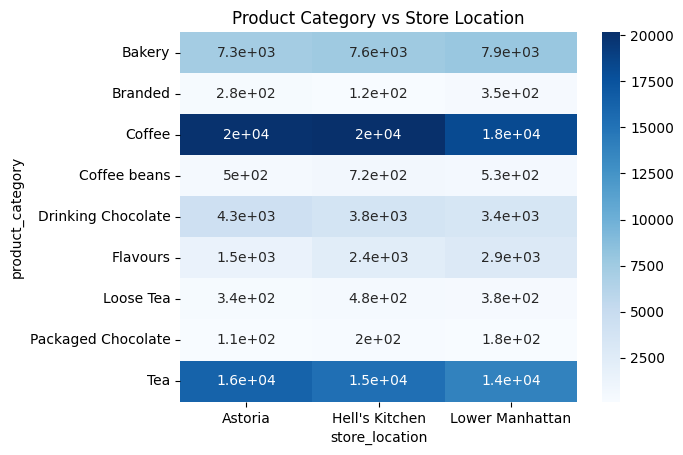

In [137]:
# Creating a crosstab to display the relation between category and location
print(pd.crosstab(shop_analysis['product_category'],shop_analysis['store_location']))
sns.heatmap(pd.crosstab(shop_analysis['product_category'],
                        shop_analysis['store_location']),
            annot=True,
            cmap="Blues")

plt.title("Product Category vs Store Location")
plt.show()

product_category  Bakery  Branded  Coffee  Coffee beans  Drinking Chocolate  \
time_of_day                                                                   
morning            13357      461   30938          1183                5955   
afternoon           6281      190   18143           373                3639   
evening             3158       96    9335           197                1874   

product_category  Flavours  Loose Tea  Packaged Chocolate    Tea  
time_of_day                                                       
morning               4698        797                 322  24040  
afternoon             1405        262                 106  14028  
evening                687        151                  59   7381  


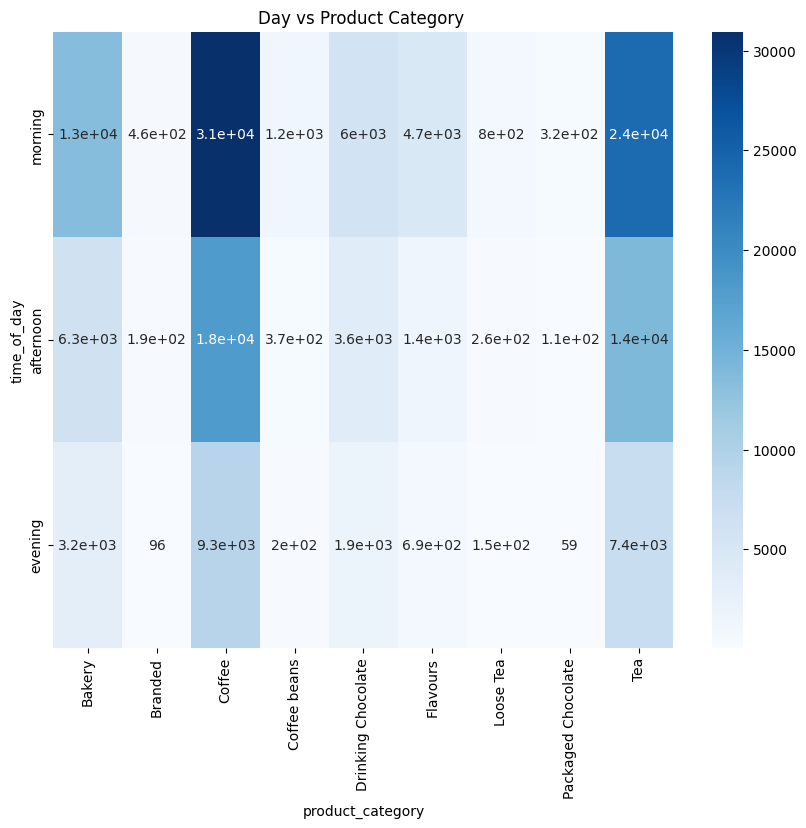

In [138]:
# Creating a crosstab to display the relation between day and category
print(pd.crosstab(shop_analysis['time_of_day'],shop_analysis['product_category']))
plt.figure(figsize=(10,8))
sns.heatmap(pd.crosstab(shop_analysis['time_of_day'],
                        shop_analysis['product_category']),
            annot=True,
            cmap="Blues")

plt.title("Day vs Product Category ")
plt.show()

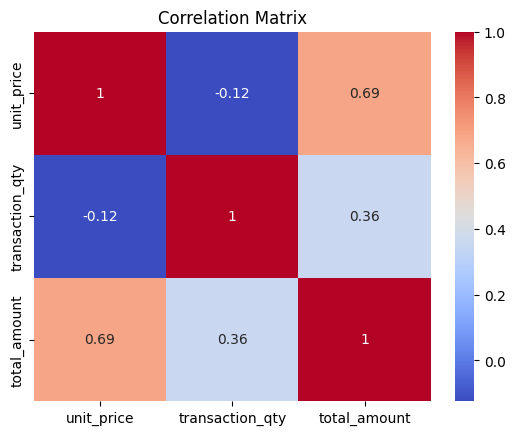

In [139]:
# Visualizing the correlation heatmap for the shop_analysis dataframe
corr = shop_analysis[['unit_price',
                      'transaction_qty',
                      'total_amount']].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

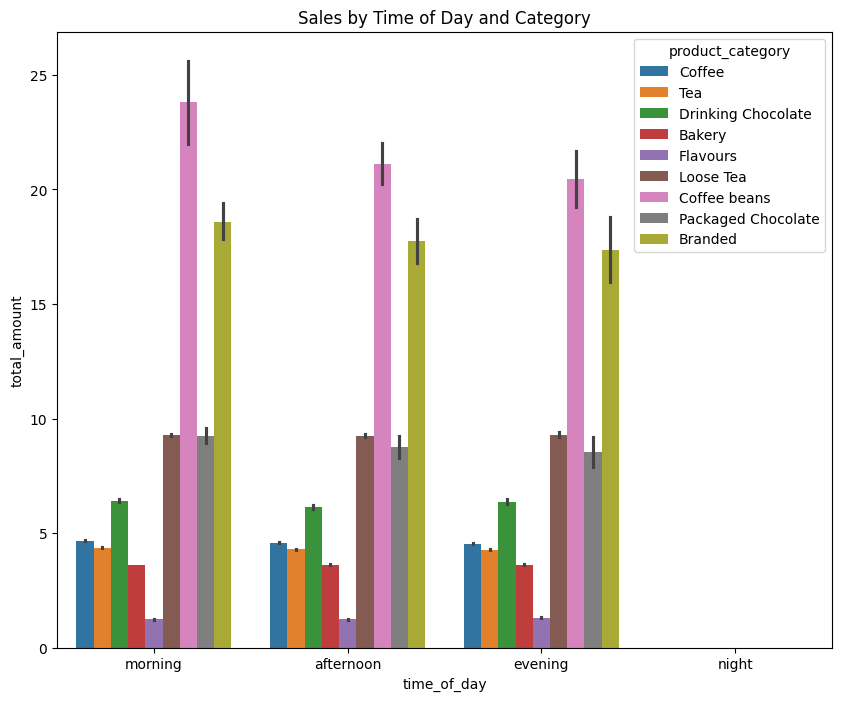

In [140]:
# Visualizing sales by category and time
plt.figure(figsize=(10,8))
sns.barplot(data=shop_analysis,
            x='time_of_day',
            y='total_amount',
            hue='product_category')

plt.title("Sales by Time of Day and Category")
plt.show()

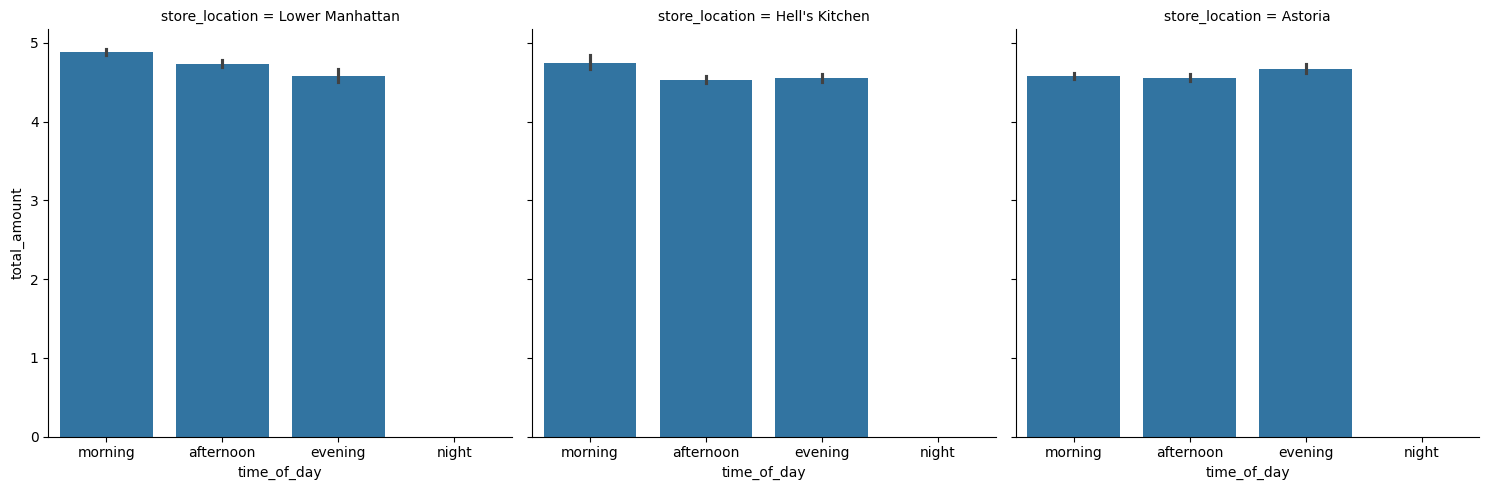

In [141]:
# Visualizing how the sales varies by time and store
sns.catplot(data=shop_analysis,
            x='time_of_day',
            y='total_amount',
            col='store_location',
            kind='bar')

#### *Insights after Bivariate and Multivariate Analysis*
- Most customers purchase only 1 product at a time, and higher the cost less quantity is purchased showing negative correlation
- As the unit_price goes up, total_amount also goes showing a positive correlation
- Most purchased item in the stores are beverages followed by bakery products
- Most transaction and purchases happen in the morning
- Coffee is the most popular product followed by Tea
- Lower Manhatten has the highest average sales out of all the location but the difference is quite small. The most propular product here is beverages and bakery
- Though June has the most sales, the most revenue is bought during the month of April
- The product Ethiopia brings in the most revenue
- Hell's Kitchens sells the most coffee whereas Astoria sells most tea
- Most of the bakery sales happen during the day
- The Coffee Shop sales declines as the time increase; which is morning has the highest sales whereas night has the lowest

#### *Key Finding and Insights*
- Beverage drives the most sales in the coffee shops across the location
- Bakery Items complement the Beverage Purchases
- Customer Spending is mostly  consistent across the stores
- Most transactions involve small quantities
- The sales gradually decline throughout the day